# Feature EDA
Examine the relationship between actual observed weather and same-day ridership.

**Sections:**
1. Setup
2. Weather overview
3. Historical vs forecast comparison (forecast quality check)
4. Weather x ridership correlations
5. Temperature effect
6. Rain effect
7. Snow effect
8. Wind effect

## 1. Setup

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv
from divvy_demand.infra.s3_client import S3Client
from divvy_demand.utils import compare_ts, error_metrics

load_dotenv("../.env")
s3 = S3Client(env="prod")

overall = s3.read_processed("overall")
overall["date"] = pd.to_datetime(overall["date"])
overall = overall.set_index("date").sort_index()

hist = s3.read_processed("weather/historical")
hist["date"] = pd.to_datetime(hist["date"])
hist = hist.set_index("date").sort_index()

fcst = s3.read_processed("weather/forecast")
fcst["date"] = pd.to_datetime(fcst["date"])
fcst = fcst.set_index("date").sort_index()

# Main analysis: actual rides + actual observed weather (same day)
df = overall.join(hist, how="left")

weather_vars = ["temp_min_c", "rain_sum_mm", "snowfall_sum_cm", "wind_speed_max_kmh"]

print("Shape:", df.shape)
df.head()

Shape: (2249, 8)


,total_rides,ebike_rides,member_rides,casual_rides,temp_min_c,rain_sum_mm,snowfall_sum_cm,wind_speed_max_kmh
date,,,,,,,,
2020-01-01,2141,0,1664,477,-6.1,0.0,0.00,35.7
2020-01-02,6479,0,5816,663,2.5,0.0,0.00,32.7
2020-01-03,5890,0,5437,453,0.2,0.0,0.00,13.4
2020-01-04,3187,0,2797,390,-2.0,0.0,1.40,21.8
2020-01-05,3035,0,2604,431,-4.8,0.0,0.07,36.0


## 2. Weather Overview

In [45]:
hist.describe()

,temp_min_c,rain_sum_mm,snowfall_sum_cm,wind_speed_max_kmh
count,2251.000000,2251.000000,2251.000000,2251.000000
mean,6.605820,2.620391,0.195571,24.164727
std,10.421102,6.880898,0.902370,7.950496
min,-24.900000,0.000000,0.000000,6.400000
25%,-1.000000,0.000000,0.000000,18.350000
50%,6.500000,0.000000,0.000000,23.200000
75%,16.200000,1.500000,0.000000,29.000000
max,25.900000,137.800000,11.760000,54.600000


In [46]:
hist.isnull().sum()

temp_min_c            0
rain_sum_mm           0
snowfall_sum_cm       0
wind_speed_max_kmh    0
dtype: int64

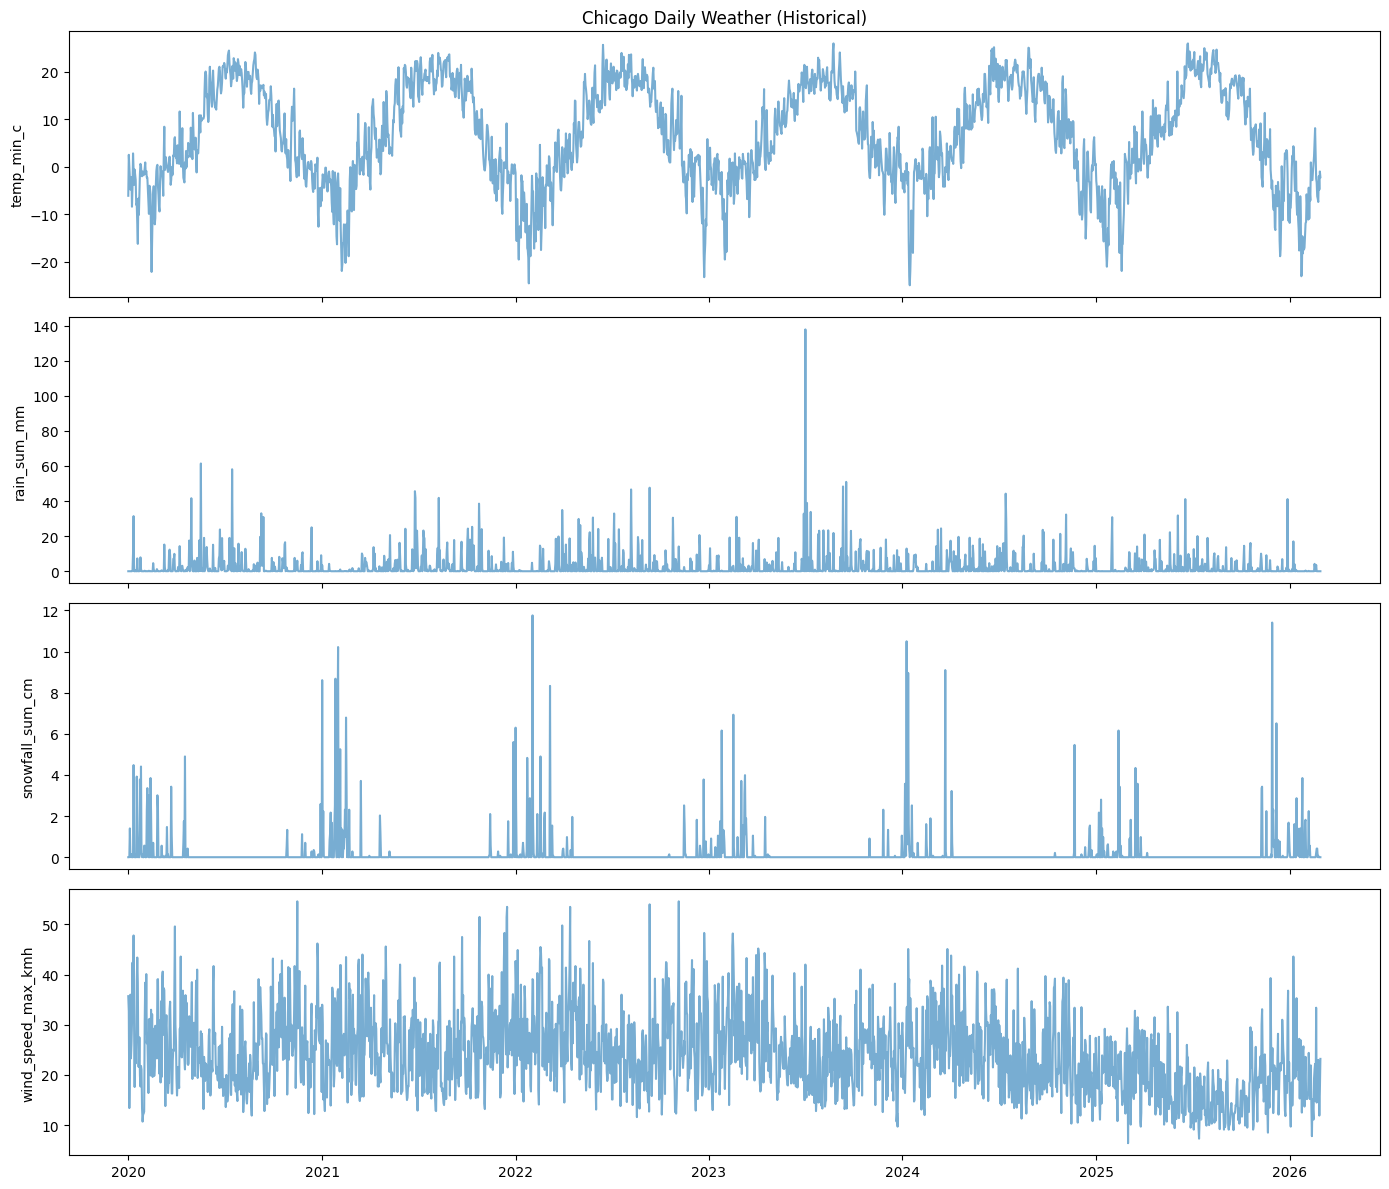

In [47]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, ["temp_min_c", "rain_sum_mm", "snowfall_sum_cm", "wind_speed_max_kmh"]):
    ax.plot(hist.index, hist[col], alpha=0.6)
    ax.set_ylabel(col)
axes[0].set_title("Chicago Daily Weather (Historical)")
plt.tight_layout()
plt.show()

## 3. Historical vs Forecast Comparison

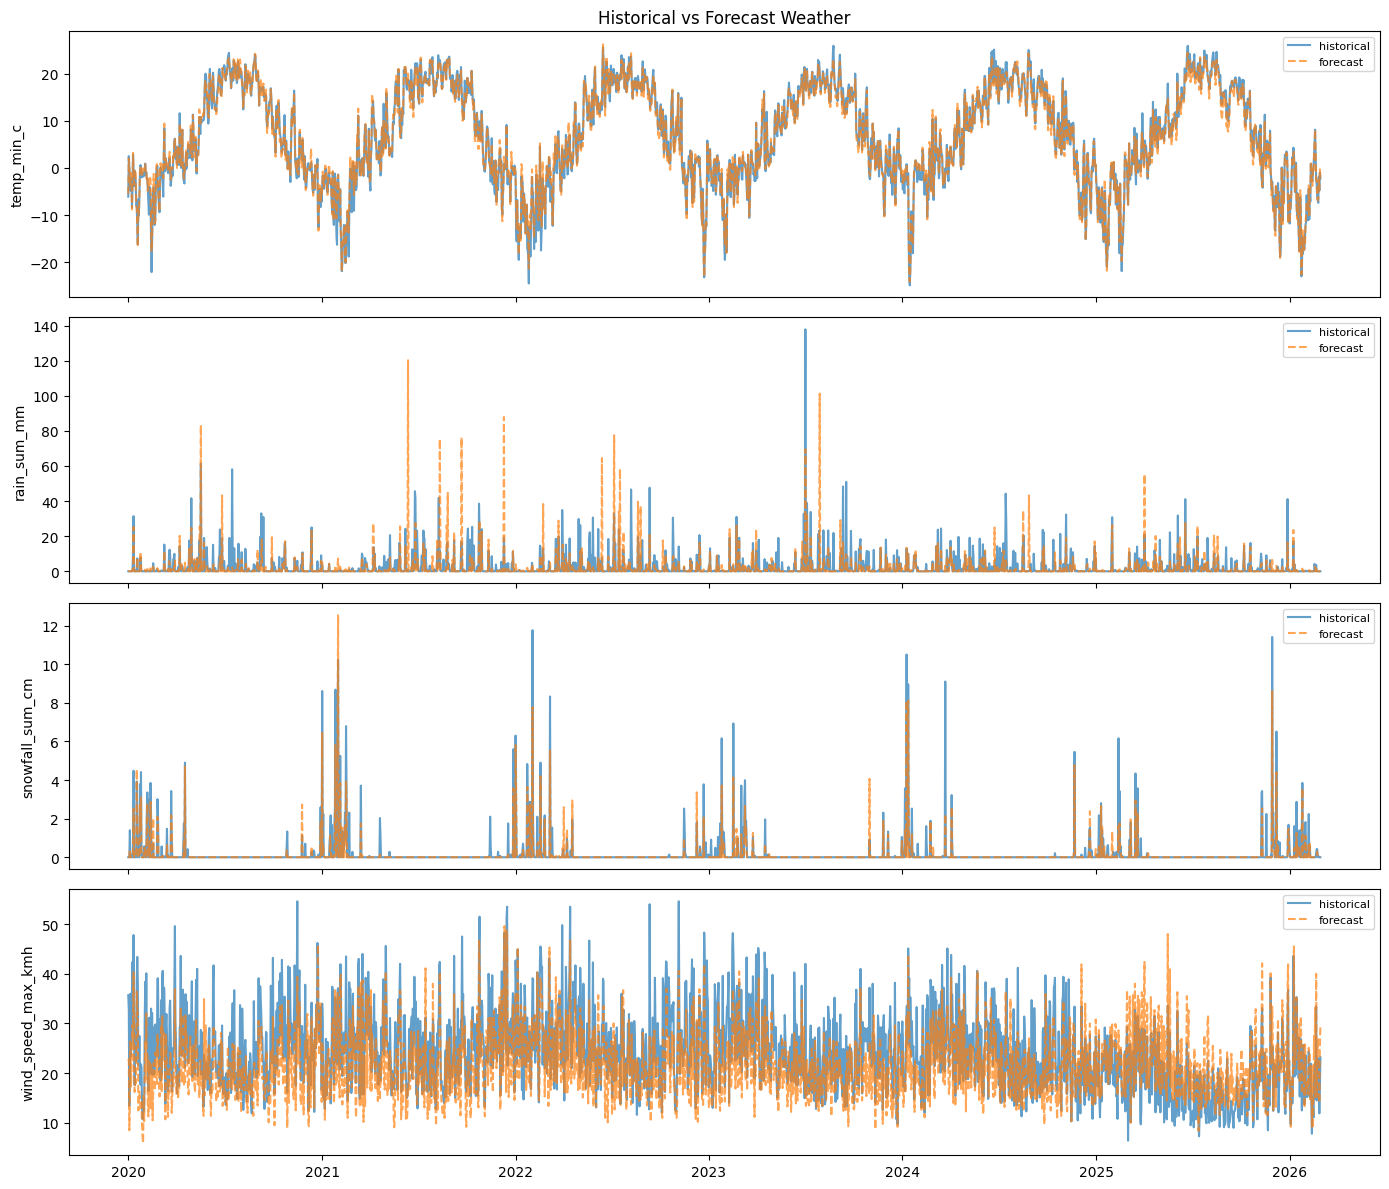

In [48]:
weather_vars = ["temp_min_c", "rain_sum_mm", "snowfall_sum_cm", "wind_speed_max_kmh"]
common_dates = hist.index.intersection(fcst.index)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, weather_vars):
    ax.plot(common_dates, hist.loc[common_dates, col], label="historical", alpha=0.7)
    ax.plot(common_dates, fcst.loc[common_dates, col], label="forecast", linestyle="--", alpha=0.7)
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
axes[0].set_title("Historical vs Forecast Weather")
plt.tight_layout()
plt.show()

In [49]:
# Error metrics per variable
from divvy_demand.utils import error_metrics

for col in weather_vars:
    h = hist.loc[common_dates, col].dropna()
    f = fcst.loc[common_dates, col].dropna()
    idx = h.index.intersection(f.index)
    m = error_metrics(h.loc[idx], f.loc[idx])
    print(f"{col:30s}  MAE={m['MAE']:.3f}  R²={m['R2']:.3f}  sMAPE={m['sMAPE']:.3f}")

temp_min_c                      MAE=0.910  R²=0.986  sMAPE=0.274
rain_sum_mm                     MAE=2.112  R²=-0.007  sMAPE=0.685
snowfall_sum_cm                 MAE=0.093  R²=0.808  sMAPE=0.161
wind_speed_max_kmh              MAE=4.756  R²=0.456  sMAPE=0.211


## 4. Weather x Ridership Correlations

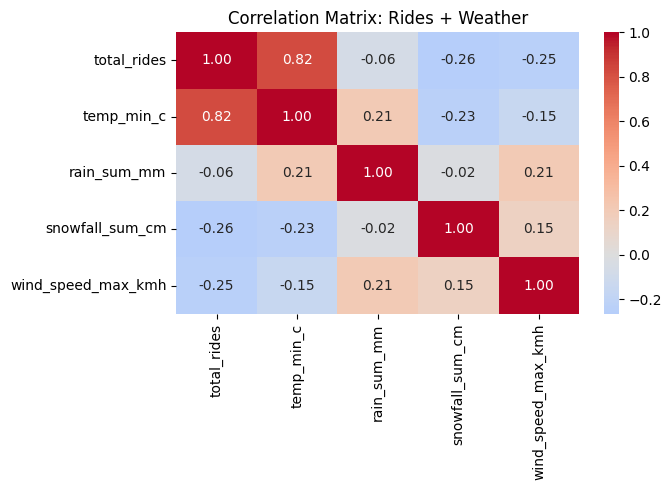

In [50]:
corr = df[["total_rides"] + weather_vars].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Rides + Weather")
plt.tight_layout()
plt.show()

## 5. Temperature Effect

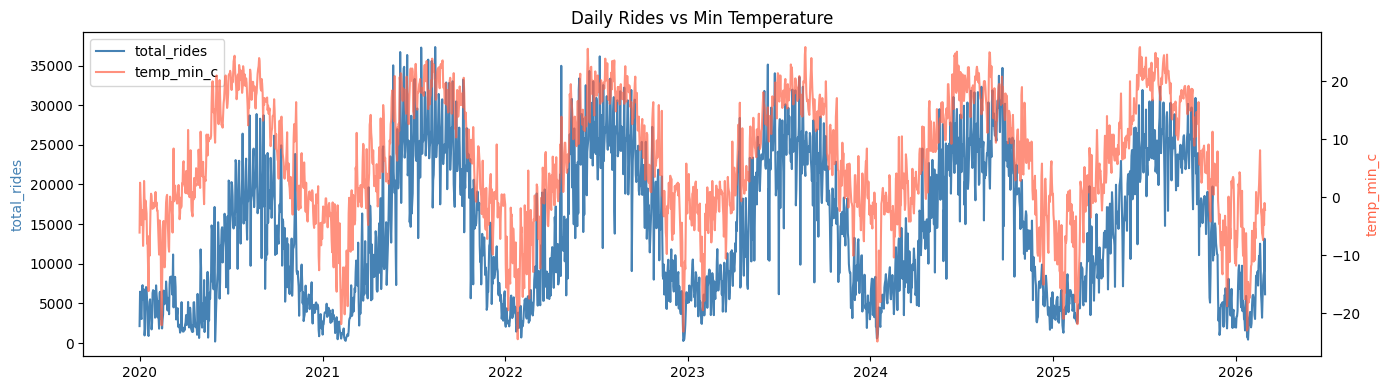

In [51]:
compare_ts(df, "total_rides", "temp_min_c", title="Daily Rides vs Min Temperature")

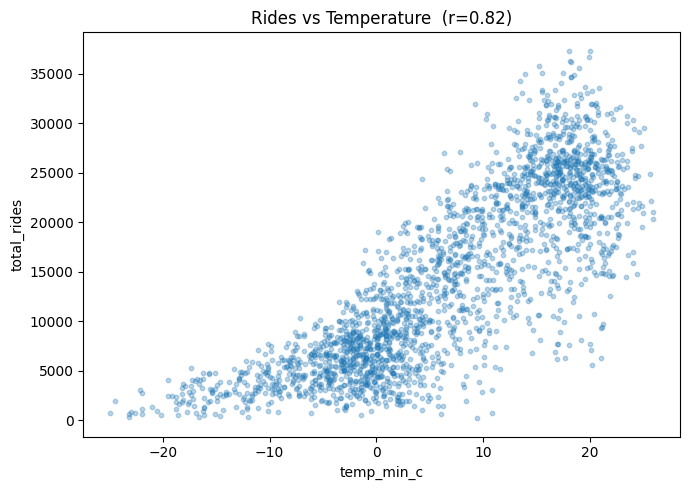

In [52]:
# Scatter
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["temp_min_c"], df["total_rides"], alpha=0.3, s=10)
ax.set_xlabel("temp_min_c")
ax.set_ylabel("total_rides")
ax.set_title(f"Rides vs Temperature  (r={df['total_rides'].corr(df['temp_min_c']):.2f})")
plt.tight_layout()
plt.show()

## 6. Rain Effect

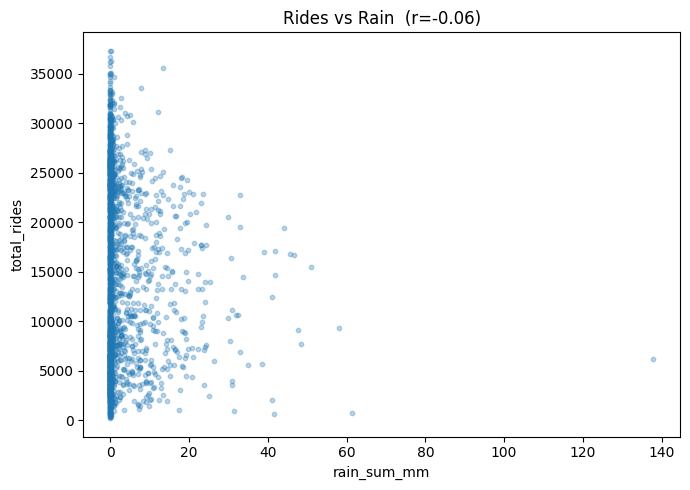

In [53]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["rain_sum_mm"], df["total_rides"], alpha=0.3, s=10)
ax.set_xlabel("rain_sum_mm")
ax.set_ylabel("total_rides")
ax.set_title(f"Rides vs Rain  (r={df['total_rides'].corr(df['rain_sum_mm']):.2f})")
plt.tight_layout()
plt.show()

Rainy mean: 14676  Dry mean: 14086  p=0.1148


/var/folders/pz/n51wnxpj59g9w6k9pl_ty57w0000gn/T/ipykernel_11772/3158501415.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dry, rainy], labels=["No Rain", "Rain"])


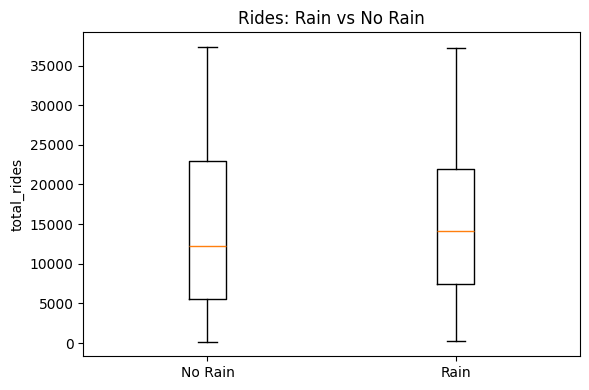

In [54]:
# Rainy vs non-rainy t-test
rainy = df[df["rain_sum_mm"] > 0]["total_rides"].dropna()
dry = df[df["rain_sum_mm"] == 0]["total_rides"].dropna()
t_stat, p_val = stats.ttest_ind(rainy, dry, equal_var=False)
print(f"Rainy mean: {rainy.mean():.0f}  Dry mean: {dry.mean():.0f}  p={p_val:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([dry, rainy], labels=["No Rain", "Rain"])
ax.set_title("Rides: Rain vs No Rain")
ax.set_ylabel("total_rides")
plt.tight_layout()
plt.show()

In [55]:
# Heavy rain (>= 75th percentile of rainy days)
q75 = df[df["rain_sum_mm"] > 0]["rain_sum_mm"].quantile(0.75)
print(f"Heavy rain threshold (Q75): {q75:.1f} mm")

heavy = df[df["rain_sum_mm"] >= q75]["total_rides"].dropna()
normal = df[df["rain_sum_mm"] < q75]["total_rides"].dropna()
t_stat, p_val = stats.ttest_ind(heavy, normal, equal_var=False)
print(f"Heavy rain mean: {heavy.mean():.0f}  Other mean: {normal.mean():.0f}  p={p_val:.4f}")

Heavy rain threshold (Q75): 7.6 mm
Heavy rain mean: 12957  Other mean: 14532  p=0.0021


## 7. Snow Effect

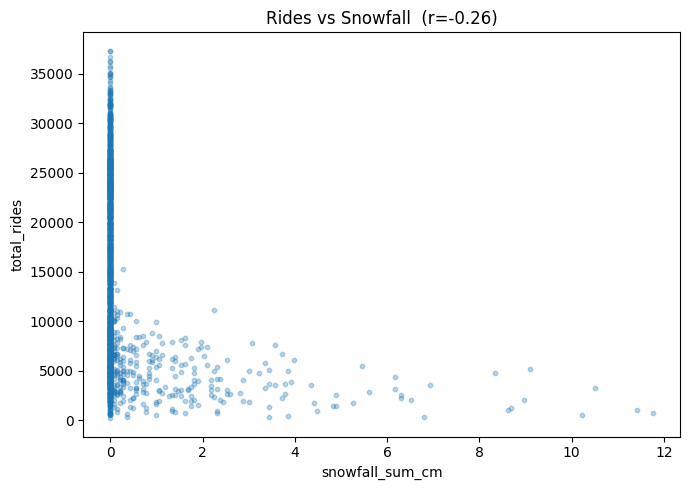

In [57]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["snowfall_sum_cm"], df["total_rides"], alpha=0.3, s=10)
ax.set_xlabel("snowfall_sum_cm")
ax.set_ylabel("total_rides")
ax.set_title(f"Rides vs Snowfall  (r={df['total_rides'].corr(df['snowfall_sum_cm']):.2f})")
plt.tight_layout()
plt.show()

Snowy mean: 4725  Clear mean: 15737  p=0.0000


/var/folders/pz/n51wnxpj59g9w6k9pl_ty57w0000gn/T/ipykernel_11772/3439654862.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([clear, snowy], labels=["No Snow", "Snow"])


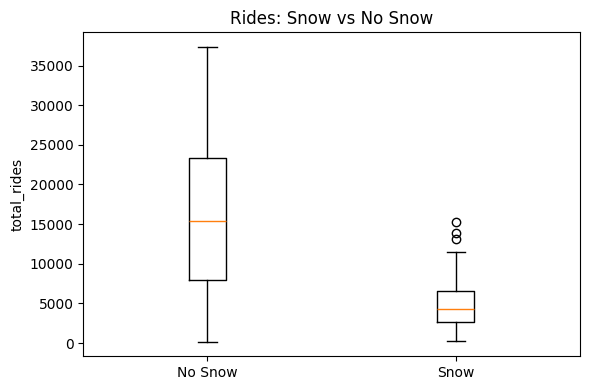

In [58]:
# Snowy vs non-snowy t-test
snowy = df[df["snowfall_sum_cm"] > 0]["total_rides"].dropna()
clear = df[df["snowfall_sum_cm"] == 0]["total_rides"].dropna()
t_stat, p_val = stats.ttest_ind(snowy, clear, equal_var=False)
print(f"Snowy mean: {snowy.mean():.0f}  Clear mean: {clear.mean():.0f}  p={p_val:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([clear, snowy], labels=["No Snow", "Snow"])
ax.set_title("Rides: Snow vs No Snow")
ax.set_ylabel("total_rides")
plt.tight_layout()
plt.show()

## 8. Wind Effect

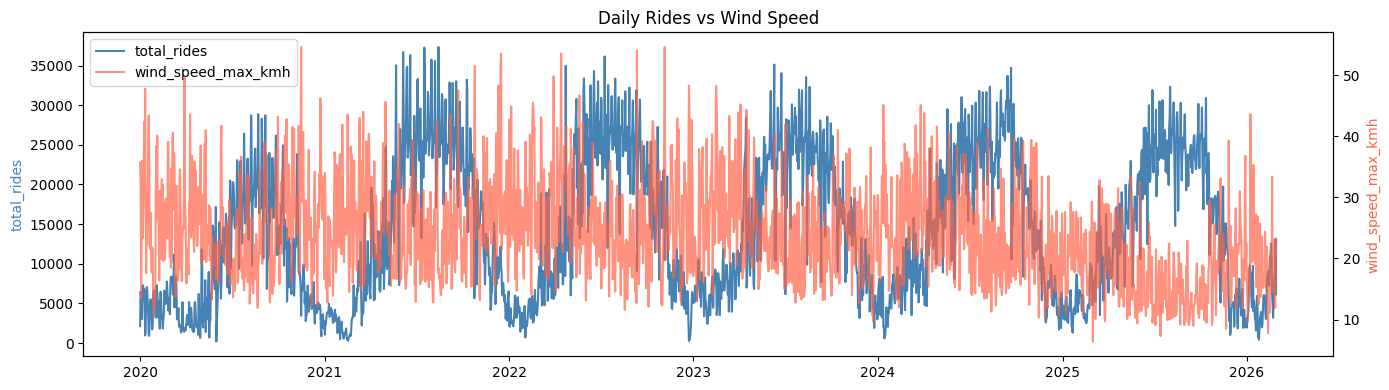

In [60]:
compare_ts(df, "total_rides", "wind_speed_max_kmh", title="Daily Rides vs Wind Speed")

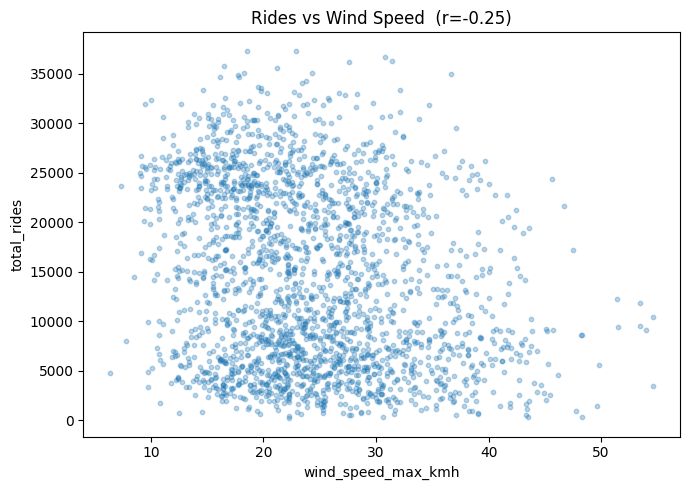

In [61]:
# Scatter + 30d MA
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["wind_speed_max_kmh"], df["total_rides"], alpha=0.3, s=10)
ax.set_xlabel("wind_speed_max_kmh")
ax.set_ylabel("total_rides")
ax.set_title(f"Rides vs Wind Speed  (r={df['total_rides'].corr(df['wind_speed_max_kmh']):.2f})")
plt.tight_layout()
plt.show()